In [1]:
# ============================================================
# STEP 1 — IMPORT LIBRARIES AND LOAD DATA
# ============================================================

# Importing all tools we need
import pandas as pd           # for reading and handling data
import numpy as np            # for mathematical operations
import matplotlib.pyplot as plt  # for basic plotting
import seaborn as sns         # for beautiful statistical plots
from scipy import stats       # for statistical tests
import statsmodels.api as sm  # for regression analysis
import warnings
warnings.filterwarnings('ignore')  # hides unnecessary warning messages

print("✓ All libraries loaded successfully")

# -------------------------------------------------------
# Loading the dataset
# -------------------------------------------------------
# pd.read_csv reads our CSV file and stores it as a table called 'df'
# 'df' stands for dataframe — think of it as an Excel sheet inside Python

df = pd.read_csv('Life Expectancy Data.csv')

print("✓ Dataset loaded successfully")
print()

# .shape tells us how many rows and columns our data has
print("Dataset Size:")
print(f"  Rows (observations): {df.shape[0]}")
print(f"  Columns (variables): {df.shape[1]}")
print()

# .head() shows us the first 5 rows so we can see what the data looks like
print("First 5 rows of the dataset:")
df.head()

✓ All libraries loaded successfully
✓ Dataset loaded successfully

Dataset Size:
  Rows (observations): 2938
  Columns (variables): 22

First 5 rows of the dataset:


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [2]:
# Now let's see all column names clearly
print("All column names in our dataset:")
print()
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

All column names in our dataset:

  1. Country
  2. Year
  3. Status
  4. Life expectancy 
  5. Adult Mortality
  6. infant deaths
  7. Alcohol
  8. percentage expenditure
  9. Hepatitis B
  10. Measles 
  11.  BMI 
  12. under-five deaths 
  13. Polio
  14. Total expenditure
  15. Diphtheria 
  16.  HIV/AIDS
  17. GDP
  18. Population
  19.  thinness  1-19 years
  20.  thinness 5-9 years
  21. Income composition of resources
  22. Schooling


In [3]:
# Let's understand what type of data each column contains
print("Data types of each column:")
print(df.dtypes)
print()

# Let's also check basic info
print("Dataset Info:")
df.info()

Data types of each column:
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

Dataset Info

In [4]:
# ============================================================
# STEP 2 — DATA CLEANING
# ============================================================

# First let's see how many missing values exist in each column
print("Missing values in each column:")
print("=" * 40)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

for col in df.columns:
    if missing[col] > 0:
        print(f"  {col}: {missing[col]} missing ({missing_pct[col]:.1f}%)")

print()
print(f"Total missing values: {df.isnull().sum().sum()}")

Missing values in each column:
  Life expectancy : 10 missing (0.3%)
  Adult Mortality: 10 missing (0.3%)
  Alcohol: 194 missing (6.6%)
  Hepatitis B: 553 missing (18.8%)
   BMI : 34 missing (1.2%)
  Polio: 19 missing (0.6%)
  Total expenditure: 226 missing (7.7%)
  Diphtheria : 19 missing (0.6%)
  GDP: 448 missing (15.2%)
  Population: 652 missing (22.2%)
   thinness  1-19 years: 34 missing (1.2%)
   thinness 5-9 years: 34 missing (1.2%)
  Income composition of resources: 167 missing (5.7%)
  Schooling: 163 missing (5.5%)

Total missing values: 2563


In [5]:
# Fill all missing numerical values with the mean of that column
# This is called mean imputation — a standard statistical technique

df.fillna(df.mean(numeric_only=True), inplace=True)

# Verify no missing values remain
remaining_missing = df.isnull().sum().sum()
print(f"✓ Missing values after cleaning: {remaining_missing}")
print("✓ Data cleaning complete")

✓ Missing values after cleaning: 0
✓ Data cleaning complete


In [6]:
# Clean up column names — some have extra spaces
# Strip whitespace from all column names
df.columns = df.columns.str.strip()

# Rename 'Life expectancy' to make it easier to type
df.rename(columns={'Life expectancy': 'Life_Expectancy'}, inplace=True)

print("✓ Column names cleaned")
print()
print("Updated column names:")
print(df.columns.tolist())

✓ Column names cleaned

Updated column names:
['Country', 'Year', 'Status', 'Life_Expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [7]:
# Let's also verify what unique values exist in the 'Status' column
# This tells us how countries are categorized
print("Unique values in Status column:")
print(df['Status'].unique())
print()
print("Count of each status:")
print(df['Status'].value_counts())

Unique values in Status column:
['Developing' 'Developed']

Count of each status:
Status
Developing    2426
Developed      512
Name: count, dtype: int64


In [8]:
# ============================================================
# STEP 3 — DESCRIPTIVE STATISTICS
# ============================================================

# Select our main variables of interest
key_vars = ['Life_Expectancy', 'Adult Mortality', 'GDP',
            'Schooling', 'HIV/AIDS', 'BMI', 'Alcohol',
            'infant deaths', 'Measles', 'Polio']

# .describe() automatically calculates count, mean, std, min, quartiles, max
desc_stats = df[key_vars].describe().round(2)

print("DESCRIPTIVE STATISTICS — KEY VARIABLES")
print("=" * 60)
print(desc_stats)

DESCRIPTIVE STATISTICS — KEY VARIABLES
       Life_Expectancy  Adult Mortality        GDP  Schooling  HIV/AIDS  \
count          2938.00          2938.00    2938.00    2938.00   2938.00   
mean             69.22           164.80    7483.16      11.99      1.74   
std               9.51           124.08   13136.80       3.26      5.08   
min              36.30             1.00       1.68       0.00      0.10   
25%              63.20            74.00     580.49      10.30      0.10   
50%              72.00           144.00    3116.56      12.10      0.10   
75%              75.60           227.00    7483.16      14.10      0.80   
max              89.00           723.00  119172.74      20.70     50.60   

           BMI  Alcohol  infant deaths    Measles    Polio  
count  2938.00  2938.00        2938.00    2938.00  2938.00  
mean     38.32     4.60          30.30    2419.59    82.55  
std      19.93     3.92         117.93   11467.27    23.35  
min       1.00     0.01           0.00   

In [9]:
# Now let's look at this more clearly — one variable at a time
# Focus on our main variable: Life Expectancy

le = df['Life_Expectancy']

print("LIFE EXPECTANCY — DETAILED SUMMARY")
print("=" * 40)
print(f"  Count         : {le.count()}")
print(f"  Mean          : {le.mean():.2f} years")
print(f"  Median        : {le.median():.2f} years")
print(f"  Std Deviation : {le.std():.2f} years")
print(f"  Minimum       : {le.min():.2f} years")
print(f"  Maximum       : {le.max():.2f} years")
print(f"  25th Percentile: {le.quantile(0.25):.2f} years")
print(f"  75th Percentile: {le.quantile(0.75):.2f} years")
print(f"  Range         : {le.max() - le.min():.2f} years")

LIFE EXPECTANCY — DETAILED SUMMARY
  Count         : 2938
  Mean          : 69.22 years
  Median        : 72.00 years
  Std Deviation : 9.51 years
  Minimum       : 36.30 years
  Maximum       : 89.00 years
  25th Percentile: 63.20 years
  75th Percentile: 75.60 years
  Range         : 52.70 years


In [10]:
# Compare developed vs developing countries
developed = df[df['Status'] == 'Developed']['Life_Expectancy']
developing = df[df['Status'] == 'Developing']['Life_Expectancy']

print("LIFE EXPECTANCY BY DEVELOPMENT STATUS")
print("=" * 50)
print(f"\n  Developed Countries:")
print(f"    Mean   : {developed.mean():.2f} years")
print(f"    Median : {developed.median():.2f} years")
print(f"    Std Dev: {developed.std():.2f} years")
print(f"    Count  : {developed.count()} observations")

print(f"\n  Developing Countries:")
print(f"    Mean   : {developing.mean():.2f} years")
print(f"    Median : {developing.median():.2f} years")
print(f"    Std Dev: {developing.std():.2f} years")
print(f"    Count  : {developing.count()} observations")

print(f"\n  Difference in Means: {developed.mean() - developing.mean():.2f} years")

LIFE EXPECTANCY BY DEVELOPMENT STATUS

  Developed Countries:
    Mean   : 79.20 years
    Median : 79.25 years
    Std Dev: 3.93 years
    Count  : 512 observations

  Developing Countries:
    Mean   : 67.12 years
    Median : 69.05 years
    Std Dev: 8.99 years
    Count  : 2426 observations

  Difference in Means: 12.08 years


In [11]:
# Frequency table for Status column
print("FREQUENCY DISTRIBUTION — COUNTRY STATUS")
print("=" * 40)
freq_table = df['Status'].value_counts()
freq_pct = df['Status'].value_counts(normalize=True) * 100

for status in freq_table.index:
    print(f"  {status}: {freq_table[status]} observations ({freq_pct[status]:.1f}%)")


FREQUENCY DISTRIBUTION — COUNTRY STATUS
  Developing: 2426 observations (82.6%)
  Developed: 512 observations (17.4%)


In [12]:
# ============================================================
# STEP 4 — GRAPHS AND VISUALIZATIONS
# ============================================================

# Set the visual style for all graphs
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

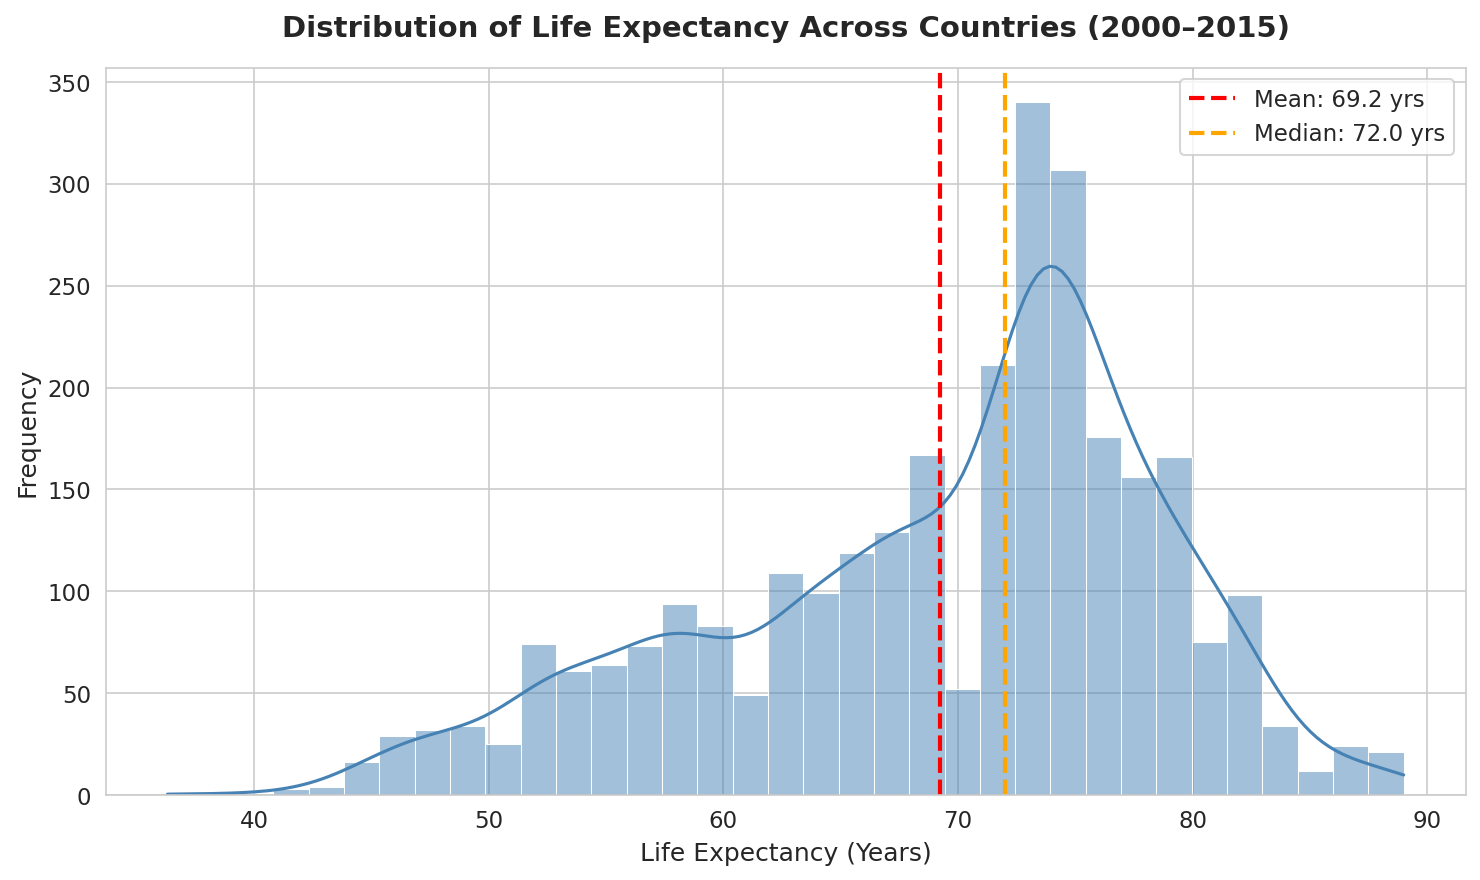

✓ Graph 1 saved as graph1_distribution.png


In [13]:
# GRAPH 1 — HISTOGRAM: Distribution of Life Expectancy
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df['Life_Expectancy'], bins=35, color='steelblue',
             kde=True, ax=ax, edgecolor='white', linewidth=0.5)

ax.set_title('Distribution of Life Expectancy Across Countries (2000–2015)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Life Expectancy (Years)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Add vertical lines for mean and median
ax.axvline(df['Life_Expectancy'].mean(), color='red', linestyle='--',
           linewidth=2, label=f"Mean: {df['Life_Expectancy'].mean():.1f} yrs")
ax.axvline(df['Life_Expectancy'].median(), color='orange', linestyle='--',
           linewidth=2, label=f"Median: {df['Life_Expectancy'].median():.1f} yrs")

ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('graph1_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 1 saved as graph1_distribution.png")

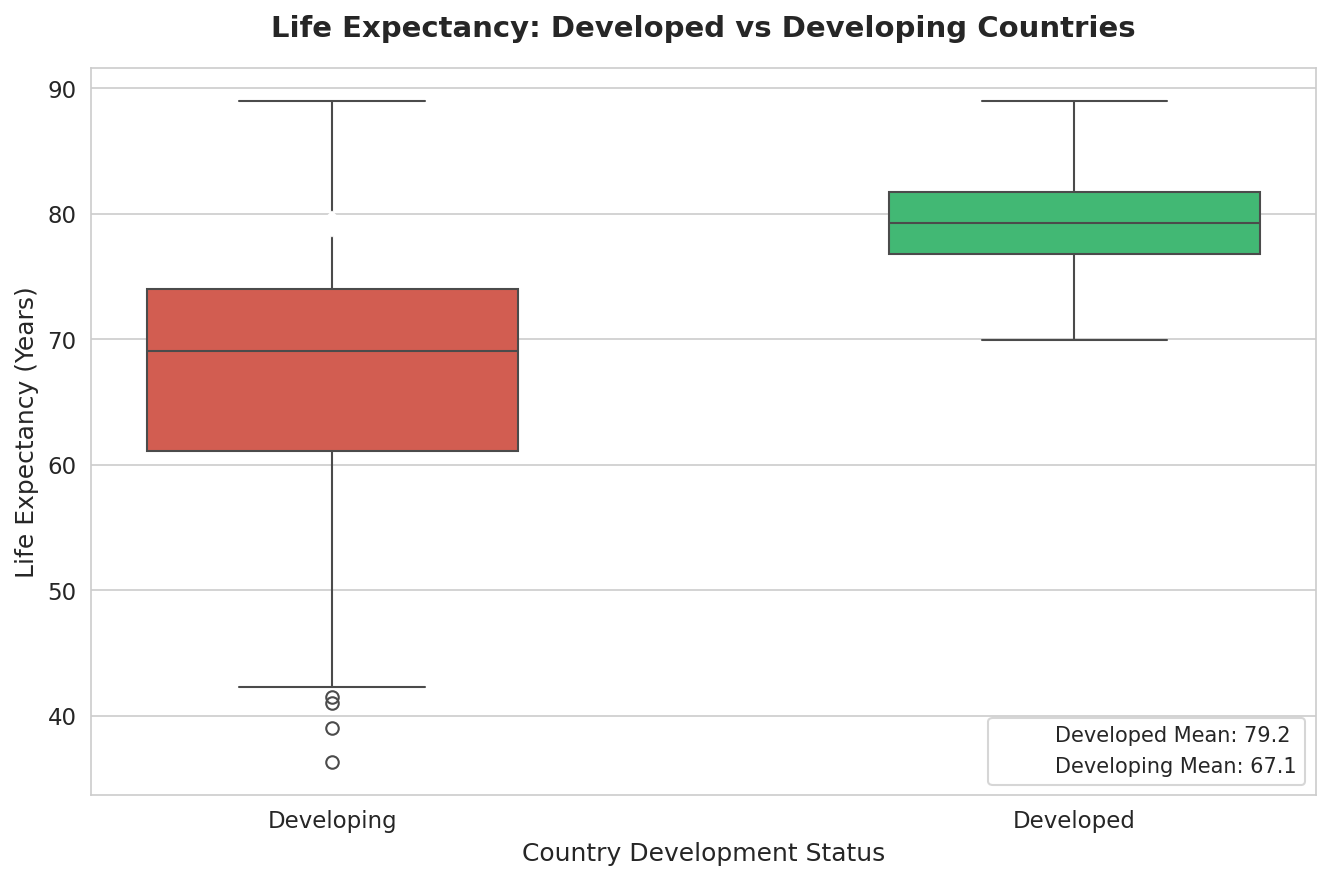

✓ Graph 2 saved as graph2_boxplot.png


In [14]:
# GRAPH 2 — BOX PLOT: Developed vs Developing Countries
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(x='Status', y='Life_Expectancy', data=df,
            palette={'Developed': '#2ecc71', 'Developing': '#e74c3c'},
            width=0.5, ax=ax)

ax.set_title('Life Expectancy: Developed vs Developing Countries',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Country Development Status', fontsize=12)
ax.set_ylabel('Life Expectancy (Years)', fontsize=12)

# Add mean markers
means = df.groupby('Status')['Life_Expectancy'].mean()
for i, status in enumerate(['Developed', 'Developing']):
    ax.plot(i, means[status], 'D', color='white',
            markersize=8, zorder=5, label=f'{status} Mean: {means[status]:.1f}')

ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('graph2_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 2 saved as graph2_boxplot.png")

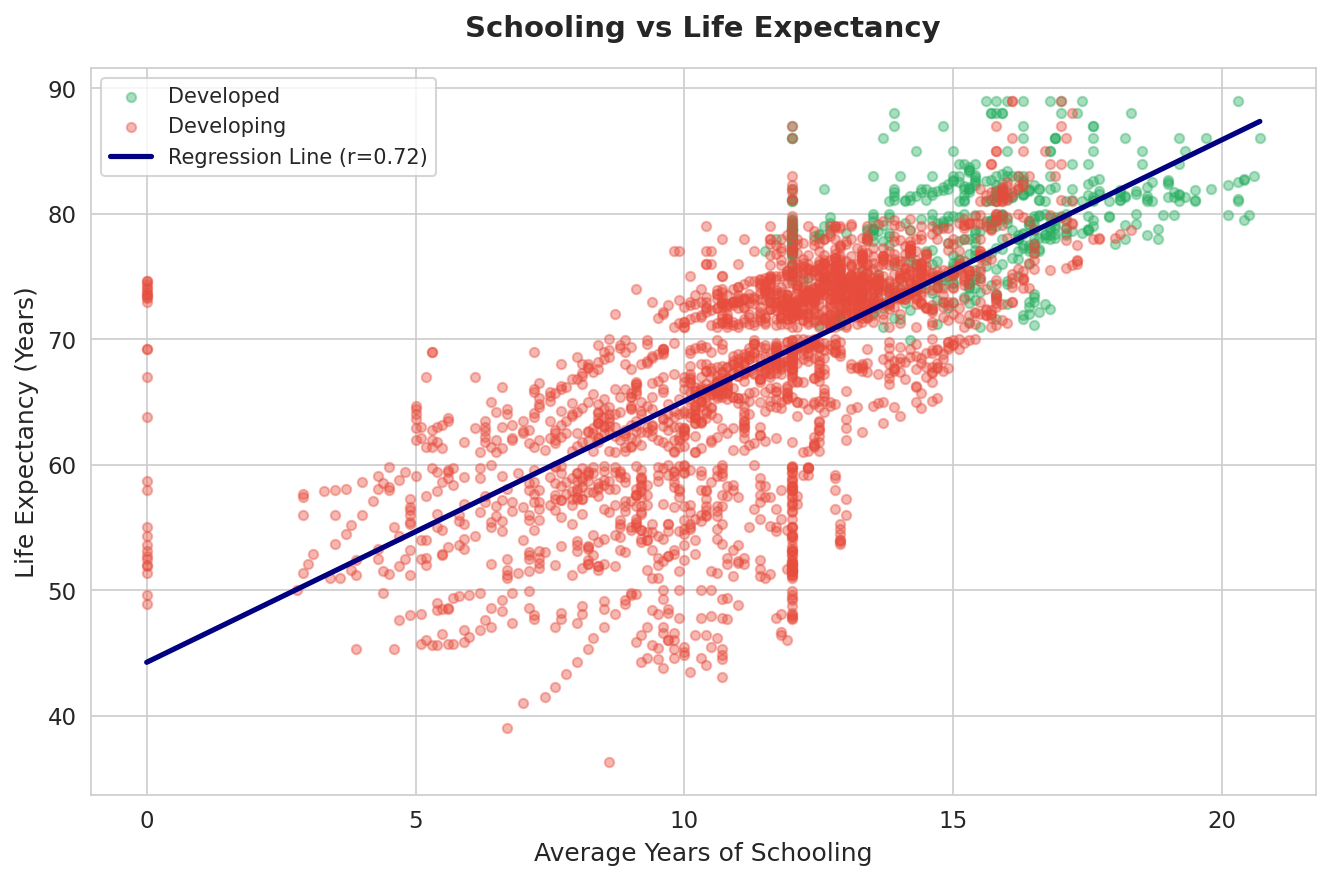

✓ Graph 3 saved as graph3_schooling.png


In [15]:
# GRAPH 3 — SCATTER PLOT: Schooling vs Life Expectancy
fig, ax = plt.subplots(figsize=(9, 6))

# Color by development status to add another layer of information
colors = {'Developed': '#27ae60', 'Developing': '#e74c3c'}
for status, group in df.groupby('Status'):
    ax.scatter(group['Schooling'], group['Life_Expectancy'],
               c=colors[status], alpha=0.4, s=20, label=status)

# Add regression line
slope, intercept, r, p, se = stats.linregress(df['Schooling'].dropna(),
                                               df['Life_Expectancy'].dropna())
x_line = np.linspace(df['Schooling'].min(), df['Schooling'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'navy', linewidth=2.5,
        label=f'Regression Line (r={r:.2f})')

ax.set_title('Schooling vs Life Expectancy',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average Years of Schooling', fontsize=12)
ax.set_ylabel('Life Expectancy (Years)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('graph3_schooling.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 3 saved as graph3_schooling.png")

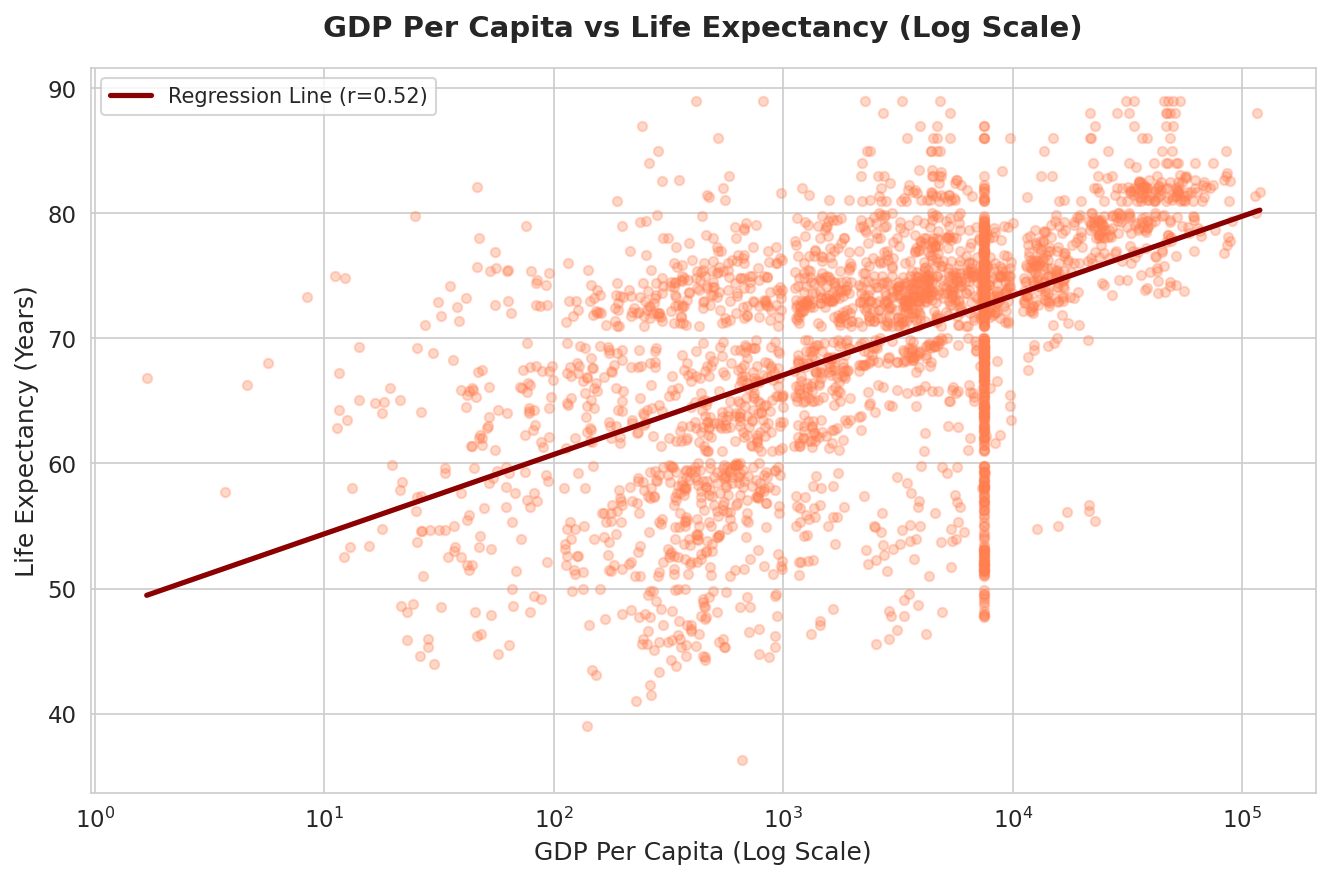

✓ Graph 4 saved as graph4_gdp.png


In [16]:
# GRAPH 4 — SCATTER PLOT: GDP vs Life Expectancy
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['GDP'], df['Life_Expectancy'],
           alpha=0.3, color='coral', s=20)

# Log scale for GDP because it has extreme values
ax.set_xscale('log')

# Add regression line on log scale
log_gdp = np.log(df[df['GDP'] > 0]['GDP'])
le_for_gdp = df[df['GDP'] > 0]['Life_Expectancy']
slope2, intercept2, r2, p2, se2 = stats.linregress(log_gdp, le_for_gdp)
x_log = np.linspace(log_gdp.min(), log_gdp.max(), 100)
ax.plot(np.exp(x_log), slope2 * x_log + intercept2,
        'darkred', linewidth=2.5, label=f'Regression Line (r={r2:.2f})')

ax.set_title('GDP Per Capita vs Life Expectancy (Log Scale)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('GDP Per Capita (Log Scale)', fontsize=12)
ax.set_ylabel('Life Expectancy (Years)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('graph4_gdp.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 4 saved as graph4_gdp.png")

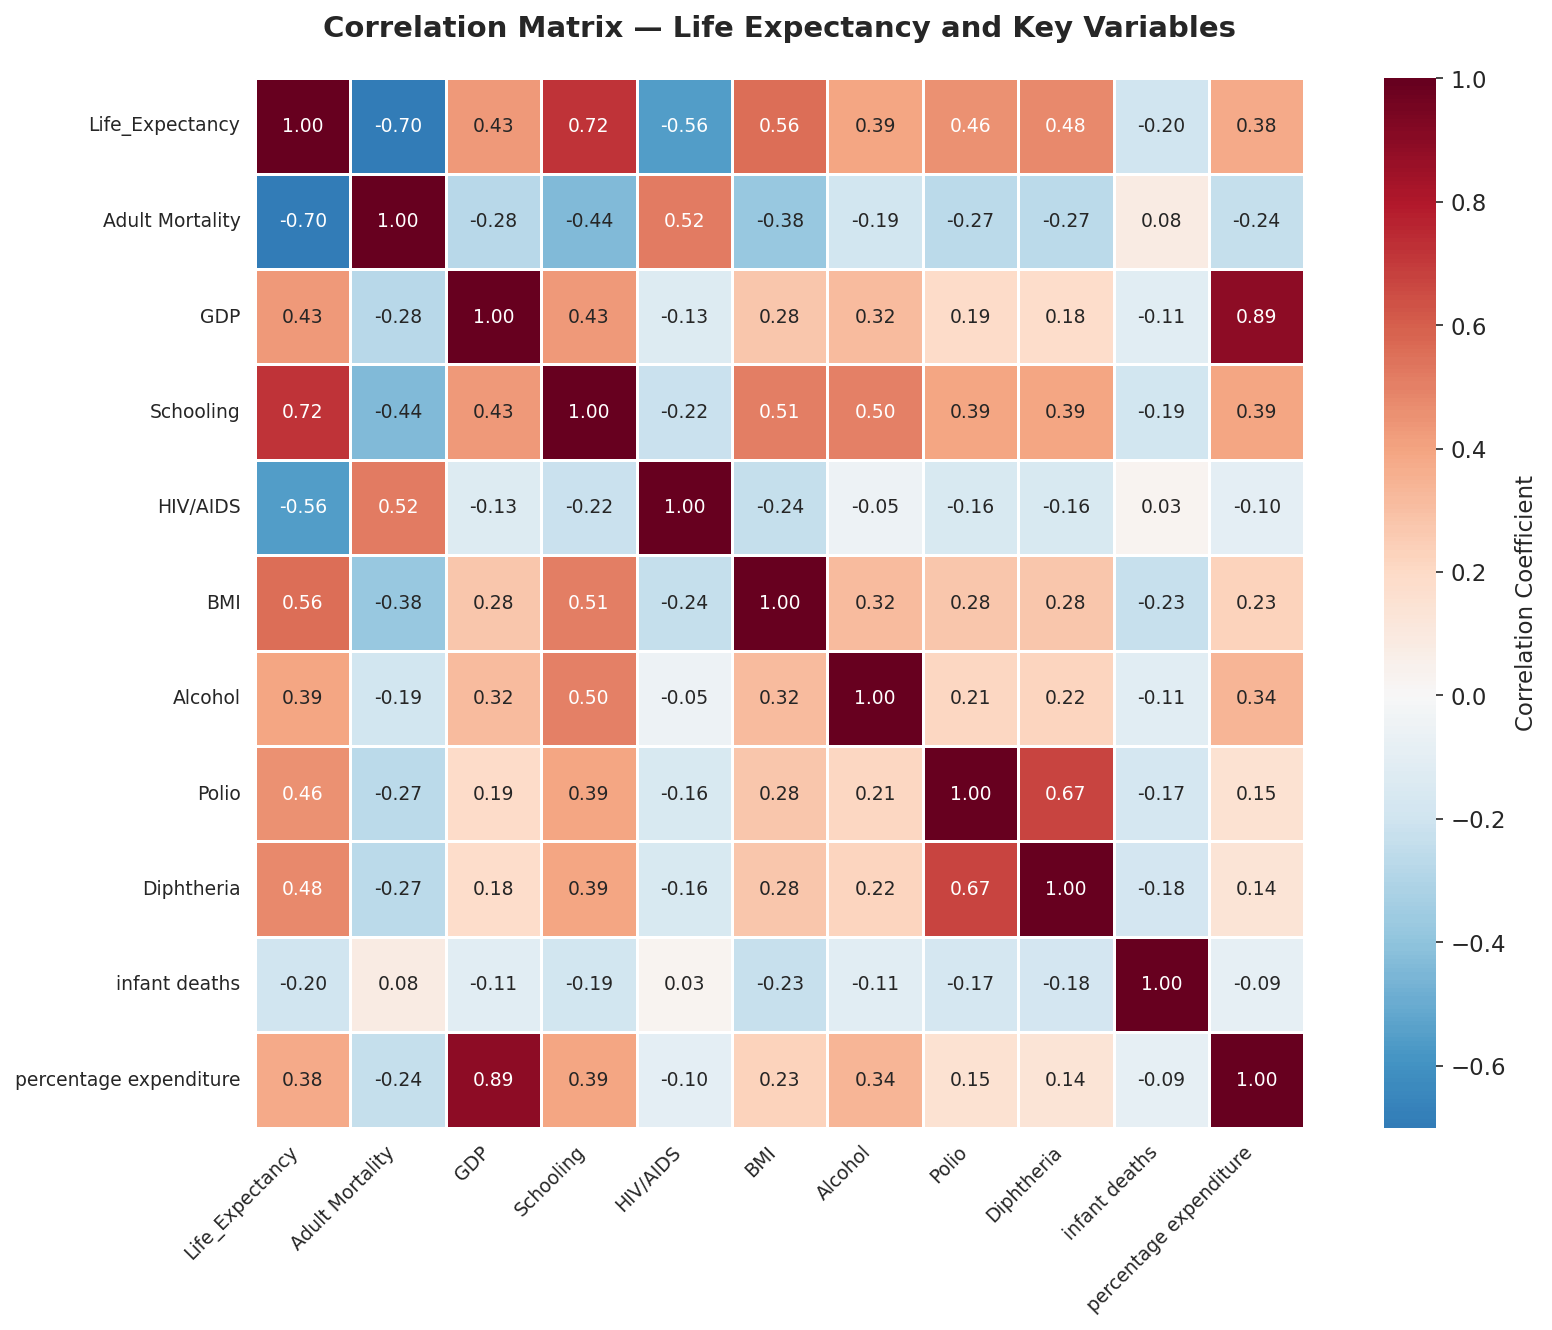

✓ Graph 5 saved as graph5_heatmap.png


In [17]:
# GRAPH 5 — CORRELATION HEATMAP
fig, ax = plt.subplots(figsize=(12, 9))

# Select variables for correlation
corr_vars = ['Life_Expectancy', 'Adult Mortality', 'GDP', 'Schooling',
             'HIV/AIDS', 'BMI', 'Alcohol', 'Polio', 'Diphtheria',
             'infant deaths', 'percentage expenditure']

corr_matrix = df[corr_vars].corr().round(2)

# Create heatmap
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # show only lower triangle

sns.heatmap(corr_matrix,
            annot=True,           # show numbers in each cell
            fmt='.2f',            # 2 decimal places
            cmap='RdBu_r',        # red = positive, blue = negative
            center=0,             # center color at 0
            square=True,          # square cells
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'},
            ax=ax,
            annot_kws={'size': 9})

ax.set_title('Correlation Matrix — Life Expectancy and Key Variables',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('graph5_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 5 saved as graph5_heatmap.png")

In [18]:
# ============================================================
# STEP 5 — CORRELATION ANALYSIS
# ============================================================

factors = {
    'Schooling': 'Average years of schooling',
    'GDP': 'GDP per capita',
    'Adult Mortality': 'Adult mortality rate',
    'HIV/AIDS': 'HIV/AIDS prevalence',
    'BMI': 'Average BMI',
    'Alcohol': 'Alcohol consumption',
    'Diphtheria': 'Diphtheria immunization coverage',
    'Polio': 'Polio immunization coverage',
    'percentage expenditure': 'Health expenditure % of GDP'
}

print("PEARSON CORRELATION ANALYSIS WITH LIFE EXPECTANCY")
print("=" * 70)
print(f"{'Factor':<30} {'r value':>10} {'p-value':>12} {'Significance':>15}")
print("-" * 70)

results = []
for col, desc in factors.items():
    # Remove rows where either variable is missing
    clean = df[['Life_Expectancy', col]].dropna()
    r, p = stats.pearsonr(clean[col], clean['Life_Expectancy'])

    # Determine significance
    if p < 0.001:
        sig = '*** (p<0.001)'
    elif p < 0.01:
        sig = '** (p<0.01)'
    elif p < 0.05:
        sig = '* (p<0.05)'
    else:
        sig = 'Not significant'

    results.append({'Factor': col, 'r': r, 'p': p, 'Significance': sig})
    print(f"  {col:<28} {r:>10.4f} {p:>12.6f} {sig:>15}")

print()
print("Interpretation Guide:")
print("  *** Very highly significant | ** Highly significant | * Significant")
print("  |r| > 0.7: Strong | 0.4–0.7: Moderate | < 0.4: Weak")

PEARSON CORRELATION ANALYSIS WITH LIFE EXPECTANCY
Factor                            r value      p-value    Significance
----------------------------------------------------------------------
  Schooling                        0.7151     0.000000   *** (p<0.001)
  GDP                              0.4305     0.000000   *** (p<0.001)
  Adult Mortality                 -0.6964     0.000000   *** (p<0.001)
  HIV/AIDS                        -0.5565     0.000000   *** (p<0.001)
  BMI                              0.5593     0.000000   *** (p<0.001)
  Alcohol                          0.3916     0.000000   *** (p<0.001)
  Diphtheria                       0.4754     0.000000   *** (p<0.001)
  Polio                            0.4616     0.000000   *** (p<0.001)
  percentage expenditure           0.3818     0.000000   *** (p<0.001)

Interpretation Guide:
  *** Very highly significant | ** Highly significant | * Significant
  |r| > 0.7: Strong | 0.4–0.7: Moderate | < 0.4: Weak


In [19]:
# Let's look at the strongest correlations in detail
print()
print("STRONGEST CORRELATIONS WITH LIFE EXPECTANCY")
print("=" * 50)

# Sort by absolute correlation value
results_sorted = sorted(results, key=lambda x: abs(x['r']), reverse=True)

for i, res in enumerate(results_sorted[:5], 1):
    direction = "positive" if res['r'] > 0 else "negative"
    print(f"\n  {i}. {res['Factor']}")
    print(f"     r = {res['r']:.4f} ({direction} relationship)")
    print(f"     p = {res['p']:.6f}")
    if abs(res['r']) > 0.7:
        strength = "strong"
    elif abs(res['r']) > 0.4:
        strength = "moderate"
    else:
        strength = "weak"
    print(f"     Strength: {strength}")


STRONGEST CORRELATIONS WITH LIFE EXPECTANCY

  1. Schooling
     r = 0.7151 (positive relationship)
     p = 0.000000
     Strength: strong

  2. Adult Mortality
     r = -0.6964 (negative relationship)
     p = 0.000000
     Strength: moderate

  3. BMI
     r = 0.5593 (positive relationship)
     p = 0.000000
     Strength: moderate

  4. HIV/AIDS
     r = -0.5565 (negative relationship)
     p = 0.000000
     Strength: moderate

  5. Diphtheria
     r = 0.4754 (positive relationship)
     p = 0.000000
     Strength: moderate


In [20]:
# ============================================================
# STEP 6 — HYPOTHESIS TESTING (INDEPENDENT SAMPLES T-TEST)
# ============================================================

developed_le = df[df['Status'] == 'Developed']['Life_Expectancy'].dropna()
developing_le = df[df['Status'] == 'Developing']['Life_Expectancy'].dropna()

# Run the independent samples t-test
t_stat, p_value = stats.ttest_ind(developed_le, developing_le)

print("INDEPENDENT SAMPLES T-TEST")
print("=" * 50)
print()
print("Null Hypothesis H₀: μ_developed = μ_developing")
print("Alt. Hypothesis H₁: μ_developed ≠ μ_developing")
print()
print(f"  Developed Countries:")
print(f"    n     = {len(developed_le)}")
print(f"    Mean  = {developed_le.mean():.4f} years")
print(f"    SD    = {developed_le.std():.4f} years")
print()
print(f"  Developing Countries:")
print(f"    n     = {len(developing_le)}")
print(f"    Mean  = {developing_le.mean():.4f} years")
print(f"    SD    = {developing_le.std():.4f} years")
print()
print(f"  T-statistic : {t_stat:.4f}")
print(f"  P-value     : {p_value:.10f}")
print()
print("CONCLUSION:")
if p_value < 0.05:
    print(f"  Since p-value ({p_value:.6f}) < 0.05,")
    print("  We REJECT the null hypothesis H₀.")
    print("  There IS a statistically significant difference")
    print("  in life expectancy between developed and developing countries.")
else:
    print(f"  Since p-value ({p_value:.6f}) > 0.05,")
    print("  We FAIL TO REJECT the null hypothesis H₀.")

INDEPENDENT SAMPLES T-TEST

Null Hypothesis H₀: μ_developed = μ_developing
Alt. Hypothesis H₁: μ_developed ≠ μ_developing

  Developed Countries:
    n     = 512
    Mean  = 79.1979 years
    SD    = 3.9309 years

  Developing Countries:
    n     = 2426
    Mean  = 67.1202 years
    SD    = 8.9885 years

  T-statistic : 29.8052
  P-value     : 0.0000000000

CONCLUSION:
  Since p-value (0.000000) < 0.05,
  We REJECT the null hypothesis H₀.
  There IS a statistically significant difference
  in life expectancy between developed and developing countries.


In [21]:
# Calculate effect size (Cohen's d) — this tells us HOW BIG the difference is
cohens_d = (developed_le.mean() - developing_le.mean()) / np.sqrt(
    ((len(developed_le)-1)*developed_le.std()**2 +
     (len(developing_le)-1)*developing_le.std()**2) /
    (len(developed_le)+len(developing_le)-2))

print()
print(f"  Cohen's d (Effect Size): {cohens_d:.4f}")
if abs(cohens_d) > 0.8:
    print("  Effect size is LARGE — the difference is practically significant")
elif abs(cohens_d) > 0.5:
    print("  Effect size is MEDIUM")
else:
    print("  Effect size is SMALL")


  Cohen's d (Effect Size): 1.4496
  Effect size is LARGE — the difference is practically significant


In [22]:
# ============================================================
# STEP 7 — MULTIPLE LINEAR REGRESSION
# ============================================================

# Select variables for regression
predictors = ['Adult Mortality', 'Schooling', 'GDP', 'HIV/AIDS', 'BMI',
              'Alcohol', 'Diphtheria', 'percentage expenditure']

# Prepare clean data (remove rows with any missing value in these columns)
reg_cols = ['Life_Expectancy'] + predictors
reg_data = df[reg_cols].dropna()

print(f"Observations used in regression: {len(reg_data)}")
print()

# Define X (predictors) and Y (outcome)
X = reg_data[predictors]
y = reg_data['Life_Expectancy']

# Add constant (this adds the intercept β₀ to our model)
X_const = sm.add_constant(X)

# Fit the Ordinary Least Squares regression model
model = sm.OLS(y, X_const).fit()

# Print the full model summary
print(model.summary())

Observations used in regression: 2938

                            OLS Regression Results                            
Dep. Variable:        Life_Expectancy   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.793
Method:                 Least Squares   F-statistic:                     1410.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:28:33   Log-Likelihood:                -8465.3
No. Observations:                2938   AIC:                         1.695e+04
Df Residuals:                    2929   BIC:                         1.700e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [23]:
# Now let's explain the output in a clean readable format
print()
print("REGRESSION RESULTS — SIMPLIFIED INTERPRETATION")
print("=" * 60)
print()
print(f"  R-squared         : {model.rsquared:.4f}")
print(f"  Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"  F-statistic       : {model.fvalue:.4f}")
print(f"  Prob (F-statistic): {model.f_pvalue:.6f}")
print()
print(f"  The model explains {model.rsquared*100:.1f}% of the variation")
print(f"  in life expectancy across countries.")
print()
print("INDIVIDUAL PREDICTORS:")
print("-" * 60)
print(f"  {'Variable':<25} {'Coefficient':>12} {'P-value':>10} {'Significant?':>12}")
print("-" * 60)

for var in model.params.index:
    coef = model.params[var]
    pval = model.pvalues[var]
    sig = "YES ***" if pval < 0.001 else ("YES **" if pval < 0.01 else ("YES *" if pval < 0.05 else "No"))
    if var == 'const':
        print(f"  {'Intercept':<25} {coef:>12.4f} {pval:>10.4f} {sig:>12}")
    else:
        print(f"  {var:<25} {coef:>12.4f} {pval:>10.4f} {sig:>12}")


REGRESSION RESULTS — SIMPLIFIED INTERPRETATION

  R-squared         : 0.7938
  Adjusted R-squared: 0.7933
  F-statistic       : 1409.7862
  Prob (F-statistic): 0.000000

  The model explains 79.4% of the variation
  in life expectancy across countries.

INDIVIDUAL PREDICTORS:
------------------------------------------------------------
  Variable                   Coefficient    P-value Significant?
------------------------------------------------------------
  Intercept                      53.0248     0.0000      YES ***
  Adult Mortality                -0.0217     0.0000      YES ***
  Schooling                       1.0064     0.0000      YES ***
  GDP                             0.0000     0.0008      YES ***
  HIV/AIDS                       -0.4899     0.0000      YES ***
  BMI                             0.0611     0.0000      YES ***
  Alcohol                         0.1173     0.0000      YES ***
  Diphtheria                      0.0636     0.0000      YES ***
  percentage ex

In [24]:
# Write out the final regression equation
print()
print("FINAL REGRESSION EQUATION:")
print("=" * 60)

# Get significant coefficients only
sig_vars = []
for var in model.params.index:
    if model.pvalues[var] < 0.05 and var != 'const':
        sig_vars.append(var)

intercept = model.params['const']
equation = f"Life Expectancy = {intercept:.2f}"
for var in sig_vars:
    coef = model.params[var]
    sign = "+" if coef > 0 else ""
    equation += f" {sign}{coef:.4f}×({var})"

print()
print(f"  {equation}")
print()

# Practical interpretation
print("PRACTICAL INTERPRETATION OF KEY COEFFICIENTS:")
print()
for var in sig_vars[:4]:  # Top 4 significant predictors
    coef = model.params[var]
    direction = "increases" if coef > 0 else "decreases"
    print(f"  → For every 1 unit increase in {var},")
    print(f"    Life Expectancy {direction} by {abs(coef):.4f} years")
    print(f"    (holding all other variables constant)")
    print()


FINAL REGRESSION EQUATION:

  Life Expectancy = 53.02 -0.0217×(Adult Mortality) +1.0064×(Schooling) +0.0000×(GDP) -0.4899×(HIV/AIDS) +0.0611×(BMI) +0.1173×(Alcohol) +0.0636×(Diphtheria)

PRACTICAL INTERPRETATION OF KEY COEFFICIENTS:

  → For every 1 unit increase in Adult Mortality,
    Life Expectancy decreases by 0.0217 years
    (holding all other variables constant)

  → For every 1 unit increase in Schooling,
    Life Expectancy increases by 1.0064 years
    (holding all other variables constant)

  → For every 1 unit increase in GDP,
    Life Expectancy increases by 0.0000 years
    (holding all other variables constant)

  → For every 1 unit increase in HIV/AIDS,
    Life Expectancy decreases by 0.4899 years
    (holding all other variables constant)



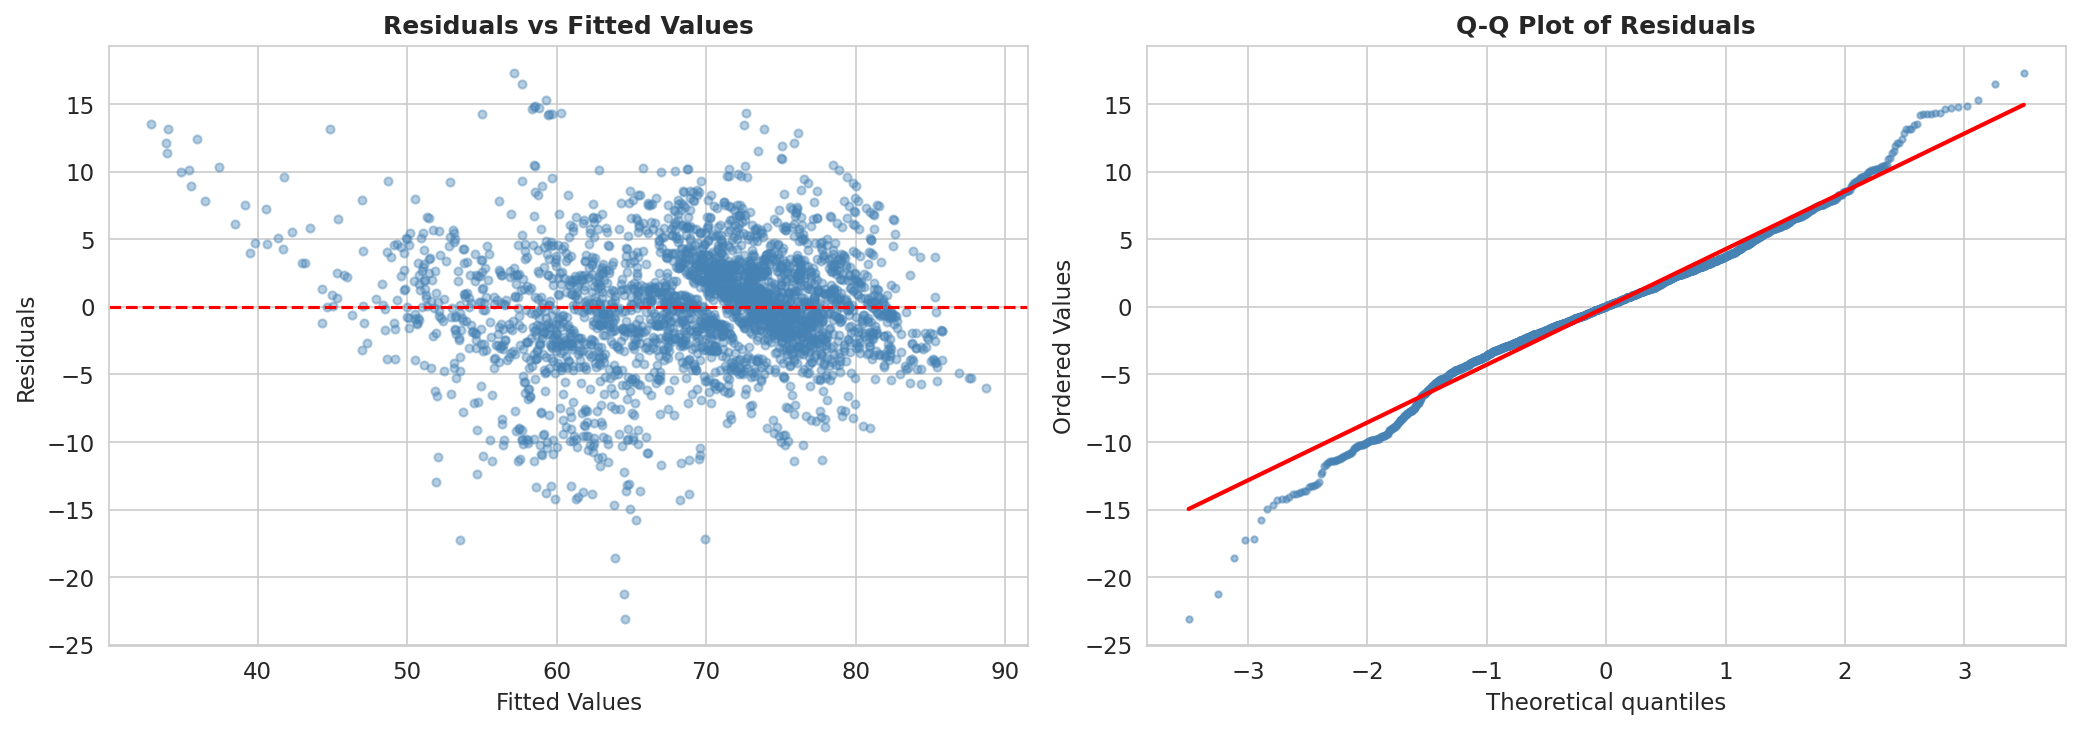

✓ Residual diagnostic plots saved


In [25]:
# Residual Plot — to check if our model assumptions are valid
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fitted vs Residuals
fitted = model.fittedvalues
residuals = model.resid

axes[0].scatter(fitted, residuals, alpha=0.4, color='steelblue', s=15)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')

# Plot 2: QQ Plot (checks if residuals are normally distributed)
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[1].get_lines()[0].set(color='steelblue', markersize=3, alpha=0.5)
axes[1].get_lines()[1].set(color='red', linewidth=2)

plt.tight_layout()
plt.savefig('graph6_residuals.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Residual diagnostic plots saved")